In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

matches = pd.read_csv('../data/matches.csv')
deliveries = pd.read_csv('../data/deliveries.csv')

team_name_map = {
    'Delhi Daredevils': 'Delhi Capitals',
    'Kings XI Punjab': 'Punjab Kings',
    'Deccan Chargers': 'Sunrisers Hyderabad',
}
for col in ['team1','team2','winner','toss_winner']:
    matches[col] = matches[col].replace(team_name_map)
for col in ['batting_team','bowling_team']:
    deliveries[col] = deliveries[col].replace(team_name_map)

matches = matches.dropna(subset=['winner'])
print("Loaded:", len(matches), "matches,", len(deliveries), "deliveries")

Loaded: 1090 matches, 260920 deliveries


Checking what the batter/bowler columns are actually called

In [2]:
print(deliveries.columns.tolist())

['match_id', 'inning', 'batting_team', 'bowling_team', 'over', 'ball', 'batter', 'bowler', 'non_striker', 'batsman_runs', 'extra_runs', 'total_runs', 'extras_type', 'is_wicket', 'player_dismissed', 'dismissal_kind', 'fielder']


In [3]:
name = "Kohli"  # try partial name first

result = deliveries[deliveries['batter'].str.contains(name, case=False, na=False)]
print(result['batter'].unique())  # see what names matched
print(result.shape)

['V Kohli' 'T Kohli']
(6256, 17)


Testing batting stats with the real name

In [4]:
full_name = result['batter'].mode()[0]
print("Using:", full_name)

batter_data = deliveries[deliveries['batter'] == full_name]

total_runs  = batter_data['batsman_runs'].sum()
matches_batted = batter_data['match_id'].nunique()
balls_faced = len(batter_data[batter_data['extras_type'] != 'wides'])
dismissals  = deliveries[deliveries['player_dismissed'] == full_name].shape[0]

average   = round(total_runs / dismissals, 2) if dismissals > 0 else "∞"
strike_rt = round((total_runs / balls_faced) * 100, 2) if balls_faced > 0 else 0

innings_runs = batter_data.groupby('match_id')['batsman_runs'].sum()
fifties  = int(((innings_runs >= 50) & (innings_runs < 100)).sum())
hundreds = int((innings_runs >= 100).sum())

print(f"Runs: {total_runs}, Matches: {matches_batted}, Avg: {average}, SR: {strike_rt}, 50s: {fifties}, 100s: {hundreds}")

Using: V Kohli
Runs: 8014, Matches: 244, Avg: 38.71, SR: 132.05, 50s: 56, 100s: 8


Test the batting chart

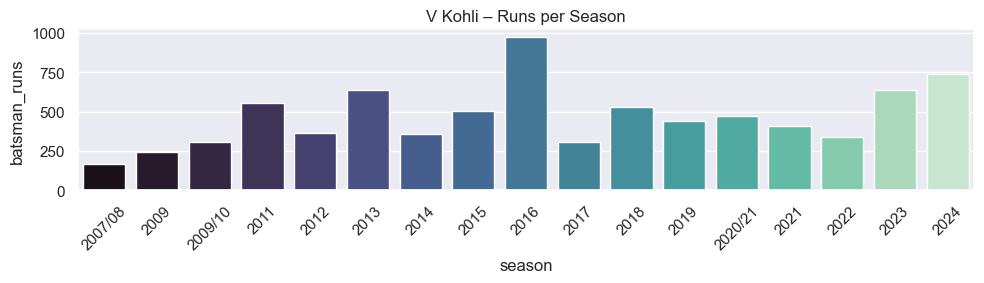

In [6]:
season_map = matches.set_index('id')['season']
batter_data = batter_data.copy()
batter_data['season'] = batter_data['match_id'].map(season_map)
season_runs_player = batter_data.groupby('season')['batsman_runs'].sum().reset_index()

sns.set_theme(style="darkgrid")
fig, ax = plt.subplots(figsize=(10, 3))
sns.barplot(
    data=season_runs_player,
    x='season',
    y='batsman_runs',
    hue='season',
    palette='mako',
    legend=False,
    ax=ax
)
ax.set_title(f"{full_name} – Runs per Season")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Test bowling stats

In [7]:
name = "Bumrah"  # test with a pure bowler

bowl_result = deliveries[deliveries['bowler'].str.contains(name, case=False, na=False)]
print(bowl_result['bowler'].unique())

full_bowl_name = bowl_result['bowler'].mode()[0]
bowler_data = deliveries[deliveries['bowler'] == full_bowl_name]

wickets_df = bowler_data[
    bowler_data['dismissal_kind'].notna() &
    ~bowler_data['dismissal_kind'].isin(['run out', 'retired hurt', 'obstructing the field'])
]

total_wickets   = len(wickets_df)
total_runs_given = bowler_data['total_runs'].sum()
balls_bowled    = len(bowler_data[bowler_data['extras_type'] != 'wides'])
economy  = round((total_runs_given / balls_bowled) * 6, 2) if balls_bowled > 0 else 0
bowl_avg = round(total_runs_given / total_wickets, 2) if total_wickets > 0 else "∞"

match_wkts = wickets_df.groupby('match_id')['dismissal_kind'].count()
match_runs_g = bowler_data.groupby('match_id')['total_runs'].sum()
best_match = match_wkts.idxmax()
best_fig = f"{match_wkts[best_match]}/{match_runs_g[best_match]}"

print(f"Wickets: {total_wickets}, Economy: {economy}, Avg: {bowl_avg}, Best: {best_fig}")

['JJ Bumrah']
Wickets: 168, Economy: 7.41, Avg: 22.86, Best: 5/29


Test with an allrounder (Jadeja)

In [8]:
# This confirms both batting AND bowling blocks will render correctly
name = "Jadeja"

bat = deliveries[deliveries['batter'].str.contains(name, case=False, na=False)]
bowl = deliveries[deliveries['bowler'].str.contains(name, case=False, na=False)]

print("Batting rows:", len(bat))
print("Bowling rows:", len(bowl))
# Both should be > 0

Batting rows: 2378
Bowling rows: 3895


Checking Fuzzy matching work

In [3]:

from thefuzz import process

# Build master player list from actual data
all_batters  = deliveries['batter'].dropna().unique().tolist()
all_bowlers  = deliveries['bowler'].dropna().unique().tolist()
all_players  = list(set(all_batters + all_bowlers))
all_players.sort()

print(f"Total unique players: {len(all_players)}")

# Test fuzzy search
query = "kohli"
matches_found = process.extract(query, all_players, limit=5)
print(matches_found)
# Should print: [('V Kohli', 90), ('AB de Villiers', 45), ...]

Total unique players: 732
[('T Kohli', 95), ('V Kohli', 95), ('T Kohler-Cadmore', 72), ('M Klinger', 64), ('AA Bilakhia', 60)]


Test the full search + filter flow

In [5]:
query = "rohit sharma"
results = process.extract(query, all_players, limit=8)

# Filter by score threshold
good_matches = [name for name, score in results if score > 60]
print(good_matches)
# ['RG Sharma', ...] — whatever the dataset calls Rohit

['H Sharma', 'I Sharma', 'R Sharma', 'RG Sharma', 'JM Sharma', 'KS Sharma', 'KV Sharma', 'MM Sharma']
